In [196]:
import control.matlab as m
import numpy as np
import pandas as pd
import scipy as sp
from sympy.abc import s,w,Q
import sympy
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

Observe effect of Quality factor on response of a system.


$T(s)=\frac{s^2}{s^2+\frac{\omega s}{Q}+\omega^2}$

In [190]:
omega=10
tf=s**2/(s**2+(w/Q)*s+w**2)
tf

s**2/(s**2 + w**2 + s*w/Q)

In [191]:

tf=tf.subs(w,omega)
copy_tf=tf
tf


s**2/(s**2 + 100 + 10*s/Q)

In [224]:
x=np.logspace(0,2,1000)
quality_f=np.linspace(1,6,10)
mags=[]
for q in quality_f:
    tf=copy_tf.subs(Q,q)
    num,den=sympy.fraction(tf)
    num_poly = sympy.Poly(num, s)
    den_poly = sympy.Poly(den, s)
    num_coeff = num_poly.all_coeffs()
    den_coeff = den_poly.all_coeffs()
    num_coeff = [float(c) for c in num_coeff]
    den_coeff = [float(c) for c in den_coeff]
    mag,phase,omega=m.bode(m.tf(num_coeff,den_coeff),plot=False)
    mags.append(mag)

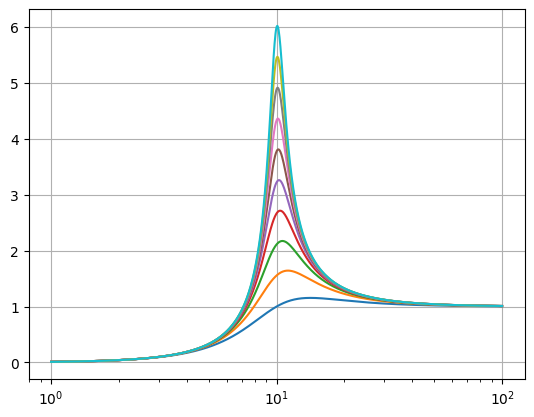

In [226]:
for mag in mags:
    plt.semilogx(x,mag)
plt.grid(True,axis='x',)
plt.grid(True)

In [27]:
from sympy import symbols
R1, R2, R3, S, C,Vin,Vout = symbols('R1 R2 R3 S C Vin Vout')
import sympy as sp

In [28]:
i_1=Vin/R1
i_2=Vout/R2
eq=sp.Eq(i_1+i_2,0)

In [29]:
eq

Eq(Vout/R2 + Vin/R1, 0)

In [30]:
solution=sp.solve(eq,Vout)

In [31]:
solution

[-R2*Vin/R1]

In [33]:
Transfer_function=sp.simplify(solution[0]/Vin)

In [34]:
Transfer_function

-R2/R1

In [2]:
import sympy as sp

R1, R2, Vin = sp.symbols('R1 R2 Vin')
Vout = Vin * (R2 / (R1 + R2))
S_R1_norm = (R1 / Vout) * sp.diff(Vout, R1)
S_R1_norm_simplified = sp.simplify(S_R1_norm)

print(S_R1_norm_simplified)

-R1/(R1 + R2)


In [5]:
E1,E2,E3,E4,R1,R2,C1,C2,Ra,Rb,S=sp.symbols("E1 E2 E3 E4 R1 R2 C1 C2 Ra Rb S")

In [6]:
i_1=E4/Ra;
i_2=(E4-E2)/Rb

In [7]:
Zb=R2+1/(S*C2)

In [9]:
E3=(Zb/(Zb+R1))*E1

In [11]:
E4=(1/(S*C2*R2+1))*E3

In [18]:
eq=sp.Eq(i_1-i_2,0)

In [20]:
eq

Eq(E4/Ra - (-E2 + E4)/Rb, 0)

In [21]:
sp.simplify(sp.solve(eq,E2)[0]/E2)

E4*(Ra - Rb)/(E2*Ra)